---
title: Pruebas estadísticas para datasets
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.2
  kernelspec:
    display_name: Python 3
    language: python
    name: python3
---



Este documento está propuesto para el análisis estadítico de diferentes datasets. Dichos datasets pueden ser importados o directamente puestos en el código.

## Bibliotecas y módulos necesarios

In [ ]:
#| warning: false
!pip install -q scikit-posthocs
import json
import io
import numpy                     as np
import matplotlib.pyplot         as plt
import seaborn                   as sns
import scikit_posthocs           as sp
import pandas                    as pd
from   scipy                     import stats
from   IPython.display           import display, Markdown
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Resumen estadístico de los datos
Únicamente para tener una descripción estadística de los datasets.
Recibe un diccionario correspondiente a un dataset y regresa sus estadísticas descriptivas.

In [ ]:
def dataset_overview(ds_dict):
    """
    Resumen estadístico del dataset
    """
    ds = ds_dict["data"]
    return {
        "samples": len(ds),
        "mean": float(np.mean(ds)),
        "median": float(np.median(ds)),
        "std": float(np.std(ds)),
        "min": float(np.min(ds)),
        "max": float(np.max(ds)),
    }

## Pruebas de normalidad y graficación

La graficación permite tener mayor certeza sobre los resultados de normalidad en el dataset


### Función de graficación
Toma los datos del dataset, su nombre, la extensión del archivo final y si se desea exportar o no.
Finalmente grafica la normalidad del dataset utilizando QQ Plot y Boxplot. Además de
un histograma de la distribución.

In [ ]:
def plot_normality(ds, ds_name, figext='eps', export=True):
    # Use a built-in style that works
    plt.style.use('default')

    # Preparar los datos - CORRECCIÓN: ds es una lista, no un DataFrame
    data = ds  # Cambiado de ds['columna'] a ds directamente

    # Crear la figura
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Use plasma colormap
    plasma_cmap = plt.cm.plasma
    colors = [plasma_cmap(0.3), plasma_cmap(0.5), plasma_cmap(0.7)]

    # QQ Plot
    stats.probplot(data, dist="norm", plot=axes[0])
    # Style the QQ plot with plasma colors
    for line in axes[0].get_lines():
        line.set_markerfacecolor(colors[0])
        line.set_markeredgecolor(colors[0])
        line.set_markersize(4)
    # Style the theoretical line
    axes[0].get_lines()[1].set_color(colors[2])  # Theoretical line
    axes[0].set_title('QQ Plot')

    # Boxplot with plasma color
    box_plot = sns.boxplot(x=data, ax=axes[1], color=colors[1])  # Añadido x=
    axes[1].set_title('Boxplot')

    # Histograma with plasma color
    hist_plot = sns.histplot(x=data, ax=axes[2], kde=True, color=colors[0])  # Añadido x=
    # Style KDE line with a different plasma color
    if hist_plot.lines:  # If KDE line exists
        hist_plot.lines[0].set_color(colors[2])
    axes[2].set_title('Histograma')

    # Optional: Set figure background to dark for plasma style
    fig.patch.set_facecolor('#0f0f23')
    for ax in axes:
        ax.set_facecolor('#0f0f23')
        ax.tick_params(colors='white')
        ax.title.set_color('white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        # Set spine colors
        for spine in ax.spines.values():
            spine.set_color('white')

    # Configurar el layout
    fig.tight_layout()

    # Título de la figura en el plot
    fig.suptitle(f'Análisis de normalidad para {ds_name}', fontsize=16, color='white')

    # Ajustar el título para no sobreponer con los demás títulos
    fig.subplots_adjust(top=0.9)

    # Guardar la figura
    if export:
        fig.savefig(f'normality_plots_{ds_name}.{figext}', format=figext.lower(), dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())

    return fig, axes

### Función de prueba de normalidad

In [ ]:
def normality_test(ds, ds_name="", plot=True):
    """Test de normalidad Shapiro-Wilk con gráficos"""
    try:
        stat, p_value = stats.shapiro(ds)

        if plot:
            # Crear gráficos
            fig, axes = plot_normality(ds, ds_name, "png", export=False)
            plt.show()

        return {
            "statistic": float(stat),
            "p_value": float(p_value),
            "method": "Shapiro-Wilk",
            "normal": p_value >= 0.05
        }
    except Exception as e:
        print(f"Error in normality_test: {e}")
        return {
            "statistic": None,
            "p_value": None,
            "method": "Shapiro-Wilk",
            "normal": None,
            "error": str(e)
        }

## Pruebas de varianza
Estas pruebas permiten saber si existe diferencia significativa entre las varianzas de los datasets analizados

In [ ]:
def levene_test(datasets, res):
    #Test de igualdad de varianzas con resultados detallados
    try:
        ds1_name = opts["ds_01_name"]
        ds2_name = opts["ds_02_name"]
        ds1_data = opts["ds_01"]
        ds2_data = opts["ds_02"]

        ds1_normal = res["normality_test"][ds1_name]["normal"]
        ds2_normal = res["normality_test"][ds2_name]["normal"]

        # Calcular estadísticas descriptivas básicas
        var1 = float(np.var(ds1_data, ddof=1))
        var2 = float(np.var(ds2_data, ddof=1))
        std1 = float(np.std(ds1_data, ddof=1))
        std2 = float(np.std(ds2_data, ddof=1))
        mean1 = float(np.mean(ds1_data))
        mean2 = float(np.mean(ds2_data))
        n1 = len(ds1_data)
        n2 = len(ds2_data)

        variance_ratio = max(var1, var2) / min(var1, var2)

        result = {
            "dataset_1": {
                "name": ds1_name,
                "n": n1,
                "mean": mean1,
                "variance": var1,
                "std_dev": std1
            },
            "dataset_2": {
                "name": ds2_name,
                "n": n2,
                "mean": mean2,
                "variance": var2,
                "std_dev": std2
            },
            "variance_ratio": float(variance_ratio),
            "test_selection_criteria": {
                "dataset_1_normal": ds1_normal,
                "dataset_2_normal": ds2_normal,
                "both_normal": ds1_normal and ds2_normal
            }
        }

        if ds1_normal and ds2_normal:
            # F-test para varianzas (paramétrico)
            df1 = n1 - 1
            df2 = n2 - 1

            # Calcular valor p para F-test
            if var1 >= var2:
                f_value = var1 / var2
                p_value = 2 * (1 - stats.f.cdf(f_value, df1, df2))
            else:
                f_value = var2 / var1
                p_value = 2 * (1 - stats.f.cdf(f_value, df2, df1))

            equal_variances = p_value >= 0.05

            result.update({
                "method": "F-Test (Parametric)",
                "statistic": float(f_value),
                "p_value": float(p_value),
                "degrees_freedom": {
                    "numerator": int(df1 if var1 >= var2 else df2),
                    "denominator": int(df2 if var1 >= var2 else df1)
                },
                "alpha_threshold": 0.05,
                "equal_variances": equal_variances,
                "test_assumptions": {
                    "normality_required": True,
                    "both_datasets_normal": True,
                    "appropriate_for": "Normal distributions"
                },
                "interpretation": {
                    "decision": "Varianzas iguales" if equal_variances else "Varianzas diferentes",
                    "reasoning": "Ambos datasets siguen distribución normal, usando F-test",
                    "p_value_interpretation": f"p-value {'≥' if equal_variances else '<'} 0.05"
                }
            })

        else:
            # Test de Levene (no paramétrico)
            stat, p_value = stats.levene(ds1_data, ds2_data)
            equal_variances = p_value >= 0.05

            result.update({
                "method": "Levene's Test (Non-parametric)",
                "statistic": float(stat),
                "p_value": float(p_value),
                "alpha_threshold": 0.05,
                "equal_variances": equal_variances,
                "test_assumptions": {
                    "normality_required": False,
                    "both_datasets_normal": False,
                    "appropriate_for": "Non-normal distributions"
                },
                "interpretation": {
                    "decision": "Varianzas iguales" if equal_variances else "Varianzas diferentes",
                    "reasoning": "Uno o ambos datasets no siguen distribución normal, usando Levene's test",
                    "p_value_interpretation": f"p-value {'≥' if equal_variances else '<'} 0.05"
                }
            })

        # Añadir evaluación numérica detallada
        result["numerical_evaluation"] = {
            "variance_difference_absolute": abs(var1 - var2),
            "variance_difference_relative": abs(var1 - var2) / min(var1, var2),
            "std_dev_ratio": max(std1, std2) / min(std1, std2),
            "confidence_interval_info": "F-test o Levene no proporcionan IC directo para la razón de varianzas"
        }

        return result

    except Exception as e:
        print(f"Error in variance_test: {e}")
        return {
            "method": "Unknown",
            "statistic": None,
            "p_value": None,
            "equal_variances": None,
            "error": str(e),
            "test_selection_criteria": {
                "dataset_1_normal": None,
                "dataset_2_normal": None,
                "both_normal": None
            }
        }

## Pruebas de media
Esta diferencia estadística significativa entre los datasets

In [ ]:
def alpha_optimizer(x, y, opts):
    """
    Optimizador del valor alpha para tests estadísticos
    Basado en el código original aportado por el Dr. Ángel
    """
    try:
        # Parámetros por defecto
        alpha_params = opts.get("alpha", {})
        alpha_list = alpha_params.get("values", [0.01, 0.05, 0.1])
        P = alpha_params.get("P", 0.4)
        k = alpha_params.get("k", 1)
        sample_size = alpha_params.get("sample_size", 6)
        replacement = alpha_params.get("sampling_with_replacement", True)
        iterations = alpha_params.get("iterations", 500)

        alpha_results = []
        beta_list = []
        expected_losses_list = []

        for alpha in alpha_list:
            rejection_count = []

            for i in range(iterations):
                # Muestreo
                sample_x = np.random.choice(x, size=sample_size, replace=replacement)
                sample_y = np.random.choice(y, size=sample_size, replace=replacement)

                # Test t
                _, p_value = stats.ttest_ind(sample_x, sample_y)

                # Contar rechazos
                rejection_count.append(1 if p_value < alpha else 0)

            # Cálculo de potencia y error tipo II
            rejected = np.sum(rejection_count)
            power = rejected / iterations
            beta = 1 - power

            # Pérdida esperada
            expected_loss = (P * alpha) + ((1 - P) * k * beta)

            beta_list.append(beta)
            expected_losses_list.append(expected_loss)
            alpha_results.append({
                "alpha": float(alpha),
                "beta": float(beta),
                "expected_loss": float(expected_loss),
                "power": float(power)
            })

        # Encontrar mejor alpha (menor pérdida esperada)
        best_idx = np.argmin(expected_losses_list)
        best_alpha = alpha_list[best_idx]

        return {
            "alpha_grid": alpha_results,
            "best_alpha": float(best_alpha),
            "min_expected_loss": float(expected_losses_list[best_idx])
        }
    except Exception as e:
        print(f"Error in alpha_optimizer: {e}")
        return {
            "alpha_grid": [],
            "best_alpha": 0.05,
            "min_expected_loss": None,
            "error": str(e)
        }



def statistical_difference_test(opts, res):
    """
    Test de diferencia estadística entre dos grupos
    """
    try:
        ds1_normal = res["normality_test"][opts["ds_01_name"]]["normal"]
        ds2_normal = res["normality_test"][opts["ds_02_name"]]["normal"]
        equal_variance = res.get("variance_test", {}).get("equal", False)

        if ds1_normal and ds2_normal:
            # T-test paramétrico
            alpha_grid = alpha_optimizer(opts["ds_01"], opts["ds_02"], opts)
            best_alpha = alpha_grid["best_alpha"]

            stat, p_value = stats.ttest_ind(opts["ds_01"], opts["ds_02"], equal_var=equal_variance)

            result = {
                "statistic": float(stat),
                "p_value": float(p_value),
                "method": "T-Test",
                "alpha_used": float(best_alpha),
                "equal": p_value >= best_alpha
            }
        else:
            # Test de Wilcoxon (no paramétrico)
            stat, p_value = stats.mannwhitneyu(opts["ds_01"], opts["ds_02"])
            result = {
                "statistic": float(stat),
                "p_value": float(p_value),
                "method": "Wilcoxon",
                "equal": p_value >= 0.05
            }

        return result
    except Exception as e:
        print(f"Error in statistical_difference_test: {e}")
        return {
            "statistic": None,
            "p_value": None,
            "method": "Unknown",
            "equal": None,
            "error": str(e)
        }

## Pruebas para multiples datasets ANNOVA/Kruskall-Wallis
Cuando se tiene más de dos datasets para analizar, es menester realizar pruebas que
permitan comparar múltiples grupos como ANOVA o Kruskal-Wallis.

### Prueba ANNOVA y prueba Kruskal-Wallis con salida detallada

In [ ]:
def anova_test(datasets, normality_results):
    """
    ANOVA de una vía para comparar múltiples grupos
    """
    try:
        # Verificar que todos los datasets sean normales
        all_normal = all(normality_results[ds["name"]]["normal"] for ds in datasets)

        if not all_normal:
            return {
                "method": "ANOVA",
                "applicable": False,
                "reason": "No todos los datasets siguen distribución normal",
                "statistic": None,
                "p_value": None,
                "significant": None
            }

        # Preparar datos para ANOVA
        data_groups = [ds["data"] for ds in datasets]
        group_names = [ds["name"] for ds in datasets]

        # Ejecutar ANOVA
        f_stat, p_value = stats.f_oneway(*data_groups)

        return {
            "method": "ANOVA (One-Way)",
            "applicable": True,
            "statistic": float(f_stat),
            "p_value": float(p_value),
            "significant": p_value < 0.05,
            "group_names": group_names,
            "group_count": len(datasets)
        }
    except Exception as e:
        print(f"Error in anova_test: {e}")
        return {
            "method": "ANOVA",
            "applicable": False,
            "reason": f"Error en cálculo: {str(e)}",
            "statistic": None,
            "p_value": None,
            "significant": None
        }

def kruskal_wallis_test(datasets):
    """
    Test de Kruskal-Wallis para comparar múltiples grupos (no paramétrico)
    """
    try:
        # Preparar datos para Kruskal-Wallis
        data_groups = [ds["data"] for ds in datasets]
        group_names = [ds["name"] for ds in datasets]

        # Ejecutar Kruskal-Wallis
        h_stat, p_value = stats.kruskal(*data_groups)

        return {
            "method": "Kruskal-Wallis",
            "applicable": True,
            "statistic": float(h_stat),
            "p_value": float(p_value),
            "significant": p_value < 0.05,
            "group_names": group_names,
            "group_count": len(datasets)
        }
    except Exception as e:
        print(f"Error in kruskal_wallis_test: {e}")
        return {
            "method": "Kruskal-Wallis",
            "applicable": False,
            "reason": f"Error en cálculo: {str(e)}",
            "statistic": None,
            "p_value": None,
            "significant": None
        }

<>:137: SyntaxWarning: invalid escape sequence '\s'
<>:137: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1656288642.py:137: SyntaxWarning: invalid escape sequence '\s'
  df_summary = pd.read_csv(io.StringIO(summary_str), sep='\s+', skiprows=2)


In [ ]:
def tukey_hsd_posthoc(datasets):
    """
    Post-hoc Tukey HSD después de ANOVA significativo - VERSIÓN CORREGIDA
    """
    try:
        # Preparar datos para Tukey HSD
        all_data = []
        all_groups = []

        for i, ds in enumerate(datasets):
            all_data.extend(ds["data"])
            all_groups.extend([ds["name"]] * len(ds["data"]))

        # Realizar Tukey HSD
        tukey = pairwise_tukeyhsd(all_data, all_groups, alpha=0.05)

        # CORRECCIÓN: Usar la interfaz pública en lugar de _results
        # Convertir resultados a formato legible
        results_data = []

        # Obtener los resultados de forma segura
        summary_data = tukey.summary()

        # En versiones recientes de statsmodels, podemos acceder a los datos así:
        if hasattr(tukey, 'results') and hasattr(tukey.results, 'data'):
            # Método para versiones más recientes
            results_array = tukey._results_table.data[1:]  # Saltar encabezados
            for row in results_array:
                results_data.append({
                    'group1': str(row[0]),
                    'group2': str(row[1]),
                    'mean_diff': float(row[2]),
                    'p_adj': float(row[3]),
                    'reject': bool(row[6])  # La columna 'reject' está en la posición 6
                })
        else:
            # Método alternativo: parsear el summary
            try:
                # Convertir el summary a DataFrame
                summary_str = str(summary_data)
                df_summary = pd.read_csv(io.StringIO(summary_str), sep='\s+', skiprows=2)
                for _, row in df_summary.iterrows():
                    results_data.append({
                        'group1': str(row['group1']),
                        'group2': str(row['group2']),
                        'mean_diff': float(row['meandiff']),
                        'p_adj': float(row['p-adj']),
                        'reject': row['reject'] == 'True'
                    })
            except:
                # Último recurso: usar representación de string
                results_data.append({
                    'method': 'Tukey HSD',
                    'summary': str(summary_data),
                    'note': 'Los datos detallados no están disponibles en este formato'
                })

        # Filtrar comparaciones significativas
        significant_pairs = [pair for pair in results_data if pair.get('reject', False)]

        return {
            "method": "Tukey HSD",
            "significant_pairs": significant_pairs,
            "all_comparisons": results_data,
            "summary": str(tukey.summary())
        }
    except Exception as e:
        print(f"Error in tukey_hsd_posthoc: {e}")
        return {
            "method": "Tukey HSD",
            "error": str(e),
            "alternative_note": "Intente actualizar statsmodels: pip install --upgrade statsmodels"
        }

def dunn_posthoc(datasets):
    """
    Post-hoc de Dunn después de Kruskal-Wallis significativo
    """
    try:
        # Preparar datos para Dunn
        all_data = []
        all_groups = []

        for i, ds in enumerate(datasets):
            all_data.extend(ds["data"])
            all_groups.extend([ds["name"]] * len(ds["data"]))

        # Realizar test de Dunn usando scikit-posthocs
        data_dict = {ds["name"]: ds["data"] for ds in datasets}
        dunn_results = sp.posthoc_dunn(data_dict, p_adjust='bonferroni')

        return {
            "method": "Dunn's test",
            "p_value_matrix": dunn_results.to_dict(),
            "significant_comparisons": []
        }
    except Exception as e:
        print(f"Error in dunn_posthoc: {e}")
        return {
            "method": "Dunn's test",
            "error": str(e)
        }

In [ ]:
def multiple_group_analysis(datasets, res):
    # Análisis completo para múltiples grupos
    try:
        multi_analysis = {
            "dataset_count": len(datasets),
            "dataset_names": [ds["name"] for ds in datasets],
            "analysis_steps": []
        }

        # Paso 1: Verificar normalidad para todos los grupos
        normality_status = all(res["normality_test"][ds["name"]]["normal"] for ds in datasets)
        multi_analysis["all_normal"] = normality_status
        multi_analysis["analysis_steps"].append("Verificación de normalidad completada")

        # Paso 2: Realizar prueba de homogeneidad de varianzas (Levene)
        try:
            levene_stat, levene_p = stats.levene(*[ds["data"] for ds in datasets])
            equal_variances = levene_p >= 0.05
            multi_analysis["variance_test"] = {
                "method": "Levene",
                "statistic": float(levene_stat),
                "p_value": float(levene_p),
                "equal_variances": equal_variances
            }
            multi_analysis["analysis_steps"].append("Prueba de homogeneidad de varianzas completada")
        except Exception as e:
            multi_analysis["variance_test"] = {"error": str(e)}

        # Paso 3: Seleccionar y ejecutar prueba apropiada
        if normality_status and multi_analysis.get("variance_test", {}).get("equal_variances", False):
            # ANOVA paramétrico
            anova_result = anova_test(datasets, res["normality_test"])
            multi_analysis["main_test"] = anova_result
            multi_analysis["analysis_steps"].append("ANOVA ejecutado")

            # Si ANOVA es significativo, realizar post-hoc
            if anova_result.get("significant"):
                posthoc_result = tukey_hsd_posthoc(datasets)
                multi_analysis["posthoc"] = posthoc_result
                multi_analysis["analysis_steps"].append("Post-hoc Tukey HSD ejecutado")
        else:
            # Kruskal-Wallis no paramétrico
            kw_result = kruskal_wallis_test(datasets)
            multi_analysis["main_test"] = kw_result
            multi_analysis["analysis_steps"].append("Kruskal-Wallis ejecutado")

            # Si Kruskal-Wallis es significativo, realizar post-hoc
            if kw_result.get("significant"):
                posthoc_result = dunn_posthoc(datasets)
                multi_analysis["posthoc"] = posthoc_result
                multi_analysis["analysis_steps"].append("Post-hoc Dunn ejecutado")

        multi_analysis["analysis_steps"].append("Análisis de múltiples grupos completado")
        return multi_analysis

    except Exception as e:
        print(f"Error in multiple_group_analysis: {e}")
        return {
            "error": str(e),
            "analysis_steps": ["Error en análisis de múltiples grupos"]
        }

### Verisón muy verbose de la cosa

In [ ]:
# ==================== VERSIÓN MEJORADA DE TUKEY HSD ====================

def tukey_hsd_posthoc_detailed(datasets, alpha=0.05):
    """
    Versión mejorada de Tukey HSD que proporciona resultados numéricos detallados
    """
    try:
        # Preparar datos
        all_data = []
        all_groups = []

        for ds in datasets:
            all_data.extend(ds["data"])
            all_groups.extend([ds["name"]] * len(ds["data"]))

        # Realizar Tukey HSD
        tukey = pairwise_tukeyhsd(all_data, all_groups, alpha=alpha)

        # Extraer información detallada
        results_data = []
        group_means = {}

        # Calcular medias por grupo para referencia
        for ds in datasets:
            group_means[ds["name"]] = np.mean(ds["data"])

        # Estrategia principal: usar la representación en DataFrame si está disponible
        try:
            # Convertir a DataFrame para un manejo más fácil
            tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                                  columns=tukey._results_table.data[0])

            for _, row in tukey_df.iterrows():
                results_data.append({
                    'group1': str(row['group1']),
                    'group2': str(row['group2']),
                    'mean_diff': float(row['meandiff']),
                    'p_adj': float(row['p-adj']),
                    'lower_ci': float(row['lower']),
                    'upper_ci': float(row['upper']),
                    'reject': bool(row['reject']),
                    'mean_group1': group_means.get(str(row['group1']), np.nan),
                    'mean_group2': group_means.get(str(row['group2']), np.nan),
                    'ci_width': float(row['upper']) - float(row['lower'])
                })

        except Exception as e:
            print(f"Error extrayendo datos detallados: {e}")
            # Fallback: usar representación básica
            summary_str = str(tukey.summary())
            results_data.append({
                'method': 'Tukey HSD',
                'summary': summary_str,
                'alpha_used': alpha,
                'note': 'Datos detallados no disponibles en este formato'
            })

        # Calcular estadísticas resumen
        significant_pairs = [pair for pair in results_data if pair.get('reject', False)]
        non_significant_pairs = [pair for pair in results_data if not pair.get('reject', True)]

        # Información sobre los grupos
        group_stats = {}
        for ds in datasets:
            data = ds["data"]
            group_stats[ds["name"]] = {
                'n': len(data),
                'mean': float(np.mean(data)),
                'std': float(np.std(data)),
                'se': float(np.std(data) / np.sqrt(len(data))),
                'ci_95_lower': float(np.mean(data) - 1.96 * np.std(data) / np.sqrt(len(data))),
                'ci_95_upper': float(np.mean(data) + 1.96 * np.std(data) / np.sqrt(len(data)))
            }

        return {
            "method": "Tukey HSD",
            "alpha_used": alpha,
            "total_comparisons": len(results_data),
            "significant_comparisons": len(significant_pairs),
            "group_statistics": group_stats,
            "significant_pairs": significant_pairs,
            "all_pairwise_comparisons": results_data,
            "test_statistics": {
                "ms_between": getattr(tukey, 'ms_between', 'N/A'),
                "ms_within": getattr(tukey, 'ms_within', 'N/A'),
                "df_between": getattr(tukey, 'df_between', 'N/A'),
                "df_within": getattr(tukey, 'df_within', 'N/A')
            },
            "critical_value": getattr(tukey, 'q_critical', 'N/A'),
            "raw_summary": str(tukey.summary()) if hasattr(tukey, 'summary') else 'N/A'
        }

    except Exception as e:
        print(f"Error in tukey_hsd_posthoc_detailed: {e}")
        return {
            "method": "Tukey HSD",
            "error": str(e),
            "alpha_used": alpha,
            "solution": "Actualizar statsmodels: pip install --upgrade statsmodels"
        }

# ==================== VERSIÓN MEJORADA DE DUNN ====================

def dunn_posthoc_detailed(datasets, alpha=0.05):
    """
    Versión mejorada del test de Dunn con resultados numéricos detallados
    """
    try:
        # Preparar datos
        data_dict = {ds["name"]: ds["data"] for ds in datasets}

        # Realizar test de Dunn
        dunn_matrix = sp.posthoc_dunn(data_dict, p_adjust='bonferroni')

        # Convertir matriz a lista de comparaciones por pares
        comparisons = []
        group_means = {}

        # Calcular medias por grupo
        for ds in datasets:
            group_means[ds["name"]] = np.mean(ds["data"])

        # Extraer todas las comparaciones por pares
        groups = list(data_dict.keys())
        for i, group1 in enumerate(groups):
            for j, group2 in enumerate(groups):
                if i < j:  # Solo comparaciones únicas
                    p_val = dunn_matrix.iloc[i, j]
                    comparisons.append({
                        'group1': group1,
                        'group2': group2,
                        'p_adj': float(p_val),
                        'reject': float(p_val) < alpha,
                        'mean_group1': group_means[group1],
                        'mean_group2': group_means[group2],
                        'mean_diff': group_means[group1] - group_means[group2],
                        'adjustment_method': 'bonferroni'
                    })

        # Estadísticas de grupos
        group_stats = {}
        for ds in datasets:
            data = ds["data"]
            group_stats[ds["name"]] = {
                'n': len(data),
                'mean': float(np.mean(data)),
                'median': float(np.median(data)),
                'std': float(np.std(data)),
                'q1': float(np.percentile(data, 25)),
                'q3': float(np.percentile(data, 75)),
                'min': float(np.min(data)),
                'max': float(np.max(data))
            }

        significant_pairs = [comp for comp in comparisons if comp['reject']]

        return {
            "method": "Dunn's test",
            "alpha_used": alpha,
            "adjustment_method": "bonferroni",
            "total_comparisons": len(comparisons),
            "significant_comparisons": len(significant_pairs),
            "group_statistics": group_stats,
            "significant_pairs": significant_pairs,
            "all_pairwise_comparisons": comparisons,
            "p_value_matrix": dunn_matrix.to_dict(),
            "test_parameters": {
                "test_type": "non-parametric",
                "assumptions": "No distributional assumptions",
                "appropriate_for": "Kruskal-Wallis post-hoc"
            }
        }

    except Exception as e:
        print(f"Error in dunn_posthoc_detailed: {e}")
        return {
            "method": "Dunn's test",
            "error": str(e),
            "alpha_used": alpha,
            "solution": "Instalar scikit-posthocs: pip install scikit-posthocs"
        }

# ==================== ANÁLISIS DE MÚLTIPLES GRUPOS MEJORADO ====================

def multiple_group_analysis_detailed(datasets, res, alpha=0.05):
    """
    Análisis completo para múltiples grupos con resultados numéricos detallados
    """
    try:
        multi_analysis = {
            "dataset_count": len(datasets),
            "dataset_names": [ds["name"] for ds in datasets],
            "alpha_level": alpha,
            "analysis_steps": [],
            "test_selection_criteria": {},
            "detailed_results": {}
        }

        # Paso 1: Verificar normalidad para todos los grupos
        normality_results = {}
        for ds in datasets:
            normality_test_result = res["normality_test"][ds["name"]]
            normality_results[ds["name"]] = {
                "normal": normality_test_result["normal"],
                "p_value": normality_test_result["p_value"],
                "statistic": normality_test_result["statistic"],
                "method": normality_test_result["method"]
            }

        normality_status = all(result["normal"] for result in normality_results.values())
        multi_analysis["all_normal"] = normality_status
        multi_analysis["normality_details"] = normality_results
        multi_analysis["analysis_steps"].append("Verificación de normalidad completada")

        # Criterio de selección de prueba
        multi_analysis["test_selection_criteria"]["normality_requirement"] = "All groups must be normal for ANOVA"
        multi_analysis["test_selection_criteria"]["current_normality_status"] = normality_status

        # Paso 2: Realizar prueba de homogeneidad de varianzas (Levene)
        try:
            levene_stat, levene_p = stats.levene(*[ds["data"] for ds in datasets])
            equal_variances = levene_p >= alpha
            multi_analysis["variance_test"] = {
                "method": "Levene",
                "statistic": float(levene_stat),
                "p_value": float(levene_p),
                "equal_variances": equal_variances,
                "alpha_threshold": alpha,
                "decision": "Equal variances" if equal_variances else "Unequal variances"
            }
            multi_analysis["test_selection_criteria"]["variance_homogeneity"] = equal_variances
            multi_analysis["analysis_steps"].append("Prueba de homogeneidad de varianzas completada")
        except Exception as e:
            multi_analysis["variance_test"] = {"error": str(e)}
            multi_analysis["test_selection_criteria"]["variance_homogeneity"] = "Unknown"

        # Paso 3: Seleccionar y ejecutar prueba apropiada
        test_decision = ""
        if normality_status and multi_analysis.get("variance_test", {}).get("equal_variances", False):
            # ANOVA paramétrico
            test_decision = "ANOVA selected: All groups normal and equal variances"
            anova_result = anova_test_detailed(datasets, normality_results, alpha)
            multi_analysis["main_test"] = anova_result
            multi_analysis["analysis_steps"].append("ANOVA ejecutado")

            # Si ANOVA es significativo, realizar post-hoc
            if anova_result.get("significant"):
                posthoc_result = tukey_hsd_posthoc_detailed(datasets, alpha)
                multi_analysis["posthoc"] = posthoc_result
                multi_analysis["analysis_steps"].append("Post-hoc Tukey HSD ejecutado")
        else:
            # Kruskal-Wallis no paramétrico
            if not normality_status:
                test_decision = "Kruskal-Wallis selected: Not all groups normal"
            else:
                test_decision = "Kruskal-Wallis selected: Unequal variances"

            kw_result = kruskal_wallis_test_detailed(datasets, alpha)
            multi_analysis["main_test"] = kw_result
            multi_analysis["analysis_steps"].append("Kruskal-Wallis ejecutado")

            # Si Kruskal-Wallis es significativo, realizar post-hoc
            if kw_result.get("significant"):
                posthoc_result = dunn_posthoc_detailed(datasets, alpha)
                multi_analysis["posthoc"] = posthoc_result
                multi_analysis["analysis_steps"].append("Post-hoc Dunn ejecutado")

        multi_analysis["test_selection_criteria"]["final_test_decision"] = test_decision
        multi_analysis["analysis_steps"].append("Análisis de múltiples grupos completado")

        # Resumen ejecutivo numérico
        multi_analysis["numerical_summary"] = create_numerical_summary(multi_analysis)

        return multi_analysis

    except Exception as e:
        print(f"Error in multiple_group_analysis_detailed: {e}")
        return {
            "error": str(e),
            "analysis_steps": ["Error en análisis de múltiples grupos"],
            "alpha_level": alpha
        }

# ==================== FUNCIONES AUXILIARES MEJORADAS ====================

def anova_test_detailed(datasets, normality_results, alpha=0.05):
    """
    ANOVA con resultados numéricos detallados
    """
    try:
        # Preparar datos para ANOVA
        data_groups = [ds["data"] for ds in datasets]
        group_names = [ds["name"] for ds in datasets]

        # Ejecutar ANOVA
        f_stat, p_value = stats.f_oneway(*data_groups)

        # Calcular estadísticas descriptivas detalladas
        group_stats = {}
        for ds in datasets:
            data = ds["data"]
            group_stats[ds["name"]] = {
                'n': len(data),
                'mean': float(np.mean(data)),
                'std': float(np.std(data)),
                'se': float(np.std(data) / np.sqrt(len(data))),
                'ci_95_lower': float(np.mean(data) - 1.96 * np.std(data) / np.sqrt(len(data))),
                'ci_95_upper': float(np.mean(data) + 1.96 * np.std(data) / np.sqrt(len(data))),
                'variance': float(np.var(data))
            }

        # Calcular SS, MS, etc. (cálculos manuales para más detalle)
        overall_mean = np.mean(np.concatenate(data_groups))
        ss_between = sum(len(group) * (np.mean(group) - overall_mean)**2 for group in data_groups)
        ss_within = sum(np.sum((group - np.mean(group))**2) for group in data_groups)
        df_between = len(data_groups) - 1
        df_within = sum(len(group) for group in data_groups) - len(data_groups)
        ms_between = ss_between / df_between
        ms_within = ss_within / df_within

        return {
            "method": "ANOVA (One-Way)",
            "applicable": True,
            "statistic": float(f_stat),
            "p_value": float(p_value),
            "significant": p_value < alpha,
            "alpha_threshold": alpha,
            "group_names": group_names,
            "group_count": len(datasets),
            "effect_size_eta_squared": float(ss_between / (ss_between + ss_within)),
            "degrees_freedom": {
                "between": df_between,
                "within": df_within,
                "total": df_between + df_within
            },
            "sum_of_squares": {
                "between": float(ss_between),
                "within": float(ss_within),
                "total": float(ss_between + ss_within)
            },
            "mean_squares": {
                "between": float(ms_between),
                "within": float(ms_within)
            },
            "group_statistics": group_stats,
            "test_assumptions": {
                "normality": True,
                "equal_variances": True,
                "independence": "Assumed"
            }
        }
    except Exception as e:
        print(f"Error in anova_test_detailed: {e}")
        return {
            "method": "ANOVA",
            "applicable": False,
            "reason": f"Error en cálculo: {str(e)}",
            "statistic": None,
            "p_value": None,
            "significant": None
        }

def kruskal_wallis_test_detailed(datasets, alpha=0.05):
    """
    Kruskal-Wallis con resultados numéricos detallados
    """
    try:
        # Preparar datos para Kruskal-Wallis
        data_groups = [ds["data"] for ds in datasets]
        group_names = [ds["name"] for ds in datasets]

        # Ejecutar Kruskal-Wallis
        h_stat, p_value = stats.kruskal(*data_groups)

        # Estadísticas no paramétricas detalladas
        group_stats = {}
        all_ranks = []
        current_rank = 1

        # Calcular rangos para todos los datos combinados
        all_data = []
        for i, group in enumerate(data_groups):
            for value in group:
                all_data.append((value, i, group_names[i]))

        # Ordenar y asignar rangos
        all_data.sort(key=lambda x: x[0])
        ranked_data = []
        for value, group_idx, group_name in all_data:
            ranked_data.append((value, group_idx, group_name, current_rank))
            current_rank += 1

        # Manejar empates
        i = 0
        while i < len(ranked_data):
            j = i
            while j < len(ranked_data) and ranked_data[j][0] == ranked_data[i][0]:
                j += 1
            if j > i + 1:  # Hay empates
                mean_rank = np.mean([ranked_data[k][3] for k in range(i, j)])
                for k in range(i, j):
                    ranked_data[k] = (ranked_data[k][0], ranked_data[k][1], ranked_data[k][2], mean_rank)
            i = j

        # Calcular estadísticas por grupo
        for ds in datasets:
            data = ds["data"]
            group_ranks = [item[3] for item in ranked_data if item[2] == ds["name"]]
            group_stats[ds["name"]] = {
                'n': len(data),
                'median': float(np.median(data)),
                'mean_rank': float(np.mean(group_ranks)) if group_ranks else 0,
                'q1': float(np.percentile(data, 25)),
                'q3': float(np.percentile(data, 75)),
                'min': float(np.min(data)),
                'max': float(np.max(data)),
                'iqr': float(np.percentile(data, 75) - np.percentile(data, 25))
            }

        return {
            "method": "Kruskal-Wallis",
            "applicable": True,
            "statistic": float(h_stat),
            "p_value": float(p_value),
            "significant": p_value < alpha,
            "alpha_threshold": alpha,
            "group_names": group_names,
            "group_count": len(datasets),
            "group_statistics": group_stats,
            "test_assumptions": {
                "ordinal_data": "Yes",
                "independence": "Assumed",
                "same_shape_distributions": "Assumed"
            },
            "test_characteristics": {
                "test_type": "non-parametric",
                "null_hypothesis": "All groups have the same median",
                "alternative_hypothesis": "At least one group has different median"
            }
        }
    except Exception as e:
        print(f"Error in kruskal_wallis_test_detailed: {e}")
        return {
            "method": "Kruskal-Wallis",
            "applicable": False,
            "reason": f"Error en cálculo: {str(e)}",
            "statistic": None,
            "p_value": None,
            "significant": None
        }

def create_numerical_summary(multi_analysis):
    """
    Crear un resumen numérico ejecutivo del análisis
    """
    summary = {
        "alpha_level": multi_analysis.get("alpha_level", "N/A"),
        "total_groups": multi_analysis.get("dataset_count", "N/A"),
        "test_used": multi_analysis.get("main_test", {}).get("method", "N/A"),
        "overall_significance": multi_analysis.get("main_test", {}).get("significant", "N/A"),
        "p_value": multi_analysis.get("main_test", {}).get("p_value", "N/A"),
        "test_statistic": multi_analysis.get("main_test", {}).get("statistic", "N/A"),
        "significant_pairwise_comparisons": len(multi_analysis.get("posthoc", {}).get("significant_pairs", [])),
        "total_pairwise_comparisons": multi_analysis.get("posthoc", {}).get("total_comparisons", "N/A")
    }

    # Añadir decisiones de selección de prueba
    test_criteria = multi_analysis.get("test_selection_criteria", {})
    summary["test_selection_reason"] = test_criteria.get("final_test_decision", "N/A")
    summary["all_groups_normal"] = multi_analysis.get("all_normal", "N/A")
    summary["equal_variances"] = test_criteria.get("variance_homogeneity", "N/A")

    return summary

# ==================== FUNCIÓN PRINCIPAL ACTUALIZADA ====================

def statistical_analysis_detailed(opts):
    """
    Función principal para el análisis estadístico completo con resultados detallados
    """
    res = {
        "normality_test": {},
        "overview": {},
        "analysis_steps": [],
        "analysis_parameters": {
            "alpha_level": opts.get("alpha", {}).get("values", [0.05])[0] if isinstance(opts.get("alpha", {}).get("values", []), list) and opts.get("alpha", {}).get("values", []) else 0.05,
            "total_datasets": 0
        }
    }

    # Detectar todos los datasets disponibles
    datasets = []
    i = 1
    while True:
        ds_key = f"ds_{i:02d}"
        ds_name_key = f"ds_{i:02d}_name"

        if ds_key in opts and opts[ds_key] is not None:
            datasets.append({
                "name": opts[ds_name_key],
                "data": opts[ds_key]
            })
            i += 1
        else:
            break

    res["analysis_parameters"]["total_datasets"] = len(datasets)
    res["analysis_steps"].append(f"Detectados {len(datasets)} datasets")

    # Análisis individual para cada dataset
    for ds in datasets:
        res["normality_test"][ds["name"]] = normality_test(ds["data"], ds["name"])
        res["overview"][ds["name"]] = dataset_overview(ds["data"])
        res["analysis_steps"].append(f"Análisis completado para {ds['name']}")

    # Decidir tipo de análisis basado en número de datasets
    alpha_level = res["analysis_parameters"]["alpha_level"]

    if len(datasets) == 2:
        # Análisis para dos grupos (existente)
        res["analysis_type"] = "Comparación de dos grupos"
        res["analysis_steps"].append("Análisis para dos grupos completado")

    elif len(datasets) >= 3:
        # Análisis para múltiples grupos (nuevo con detalles numéricos)
        res["multiple_group_analysis"] = multiple_group_analysis_detailed(datasets, res, alpha_level)
        res["analysis_type"] = f"Comparación de {len(datasets)} grupos"
        res["analysis_steps"].append("Análisis para múltiples grupos completado")

    else:
        res["analysis_type"] = "Análisis descriptivo individual"
        res["analysis_steps"].append("Solo análisis descriptivo realizado")

    # Guardar resultados
    save_results(res)
    return res

## Exportación de los resultados

In [ ]:
def safe_format_value(value, format_spec=".4f", default="N/A"):
    """Formatear valores de manera segura, manejando None"""
    if value is None:
        return default
    try:
        # Si es numérico, formatear
        if isinstance(value, (int, float, np.number)):
            return f"{value:{format_spec}}"
        # Si es booleano, convertir a texto
        elif isinstance(value, bool):
            return "Sí" if value else "No"
        # Si ya es string, devolver tal cual
        elif isinstance(value, str):
            return value
        # Para otros tipos, convertirlos a string
        else:
            return str(value)
    except (ValueError, TypeError) as e:
        return str(value) if value is not None else default

def safe_serialize(obj):
    """
    Serializar objetos de forma segura para JSON, manejando tipos de numpy
    """
    if obj is None:
        return None
    elif isinstance(obj, (bool, int, float, str)):
        return obj
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: safe_serialize(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [safe_serialize(item) for item in obj]
    elif isinstance(obj, tuple):
        return [safe_serialize(item) for item in obj]
    elif hasattr(obj, '__dict__'):
        return safe_serialize(obj.__dict__)
    else:
        try:
            return str(obj)
        except Exception:
            return "Non-serializable object"


def display_variance_test_results(variance_results):
    """Mostrar resultados detallados de la prueba de varianzas"""

    if not variance_results:
        display(Markdown("### ❌ No hay resultados de prueba de varianzas"))
        return

    display(Markdown("### 📊 Prueba de Homogeneidad de Varianzas - Resultados Detallados"))

    # Información de los datasets
    display(Markdown("#### 📈 Estadísticas Descriptivas de los Datasets"))
    stats_data = []

    ds1 = variance_results["dataset_1"]
    ds2 = variance_results["dataset_2"]

    stats_data.append({
        "Dataset": ds1["name"],
        "Muestras (n)": ds1["n"],
        "Media": safe_format_value(ds1["mean"]),
        "Varianza": safe_format_value(ds1["variance"]),
        "Desv. Estándar": safe_format_value(ds1["std_dev"])
    })

    stats_data.append({
        "Dataset": ds2["name"],
        "Muestras (n)": ds2["n"],
        "Media": safe_format_value(ds2["mean"]),
        "Varianza": safe_format_value(ds2["variance"]),
        "Desv. Estándar": safe_format_value(ds2["std_dev"])
    })

    stats_df = pd.DataFrame(stats_data)
    display(stats_df)

    # Criterios de selección de prueba
    display(Markdown("#### 🔍 Criterios de Selección de Prueba"))
    criteria = variance_results["test_selection_criteria"]
    criteria_data = [
        {"Criterio": f"{ds1['name']} es normal", "Valor": "✅ Sí" if criteria["dataset_1_normal"] else "❌ No"},
        {"Criterio": f"{ds2['name']} es normal", "Valor": "✅ Sí" if criteria["dataset_2_normal"] else "❌ No"},
        {"Criterio": "Ambos datasets normales", "Valor": "✅ Sí" if criteria["both_normal"] else "❌ No"},
        {"Criterio": "Prueba seleccionada", "Valor": variance_results["method"]}
    ]
    criteria_df = pd.DataFrame(criteria_data)
    display(criteria_df)

    # Resultados de la prueba
    display(Markdown("#### 🧪 Resultados de la Prueba Estadística"))
    test_data = [
        {"Métrica": "Método", "Valor": variance_results["method"]},
        {"Métrica": "Estadístico de prueba", "Valor": safe_format_value(variance_results["statistic"])},
        {"Métrica": "Valor p", "Valor": safe_format_value(variance_results["p_value"])},
        {"Métrica": "Umbral alpha", "Valor": safe_format_value(variance_results["alpha_threshold"])},
        {"Métrica": "Razón de varianzas", "Valor": safe_format_value(variance_results["variance_ratio"])}
    ]

    # Añadir grados de libertad para F-test
    if "degrees_freedom" in variance_results:
        df = variance_results["degrees_freedom"]
        test_data.append({"Métrica": "GL Numerador", "Valor": df["numerator"]})
        test_data.append({"Métrica": "GL Denominador", "Valor": df["denominator"]})

    test_data.append({
        "Métrica": "¿Varianzas iguales?",
        "Valor": "✅ Sí" if variance_results["equal_variances"] else "❌ No"
    })

    test_df = pd.DataFrame(test_data)
    display(test_df)

    # Evaluación numérica adicional
    if "numerical_evaluation" in variance_results:
        display(Markdown("#### 📐 Evaluación Numérica Adicional"))
        eval_data = []
        numerical_eval = variance_results["numerical_evaluation"]

        eval_data.append({
            "Métrica": "Diferencia absoluta de varianzas",
            "Valor": safe_format_value(numerical_eval["variance_difference_absolute"])
        })

        eval_data.append({
            "Métrica": "Diferencia relativa de varianzas",
            "Valor": safe_format_value(numerical_eval["variance_difference_relative"])
        })

        eval_data.append({
            "Métrica": "Razón de desviaciones estándar",
            "Valor": safe_format_value(numerical_eval["std_dev_ratio"])
        })

        eval_df = pd.DataFrame(eval_data)
        display(eval_df)

    # Interpretación
    display(Markdown("#### 📝 Interpretación"))
    interpretation = variance_results["interpretation"]

    display(Markdown(f"**Decisión:** {interpretation['decision']}"))
    display(Markdown(f"**Razonamiento:** {interpretation['reasoning']}"))
    display(Markdown(f"**Interpretación del p-value:** {interpretation['p_value_interpretation']}"))

    # Supuestos de la prueba
    display(Markdown("#### 📋 Supuestos de la Prueba"))
    assumptions = variance_results["test_assumptions"]
    assumptions_data = [
        {"Supuesto": "Normalidad requerida", "Cumplido": "✅ Sí" if assumptions["normality_required"] else "❌ No"},
        {"Supuesto": "Ambos datasets normales", "Cumplido": "✅ Sí" if assumptions["both_datasets_normal"] else "❌ No"},
        {"Supuesto": "Prueba apropiada para", "Cumplido": assumptions["appropriate_for"]}
    ]
    assumptions_df = pd.DataFrame(assumptions_data)
    display(assumptions_df)

def save_results(res):
    """
    Guardar resultados en archivo JSON de forma segura
    """
    try:
        # Serializar de forma segura
        serializable_res = safe_serialize(res)

        with open("statistical_analysis_results.json", "w") as f:
            json.dump(serializable_res, f, indent=2, ensure_ascii=False)
        print("Results successfully saved to statistical_analysis_results.json")
    except Exception as e:
        print(f"Error saving results: {e}")
        # Fallback: save basic information
        basic_results = {
            "overview": res.get("overview", {}),
            "normality_summary": {
                name: {
                    "normal": test.get("normal"),
                    "p_value": test.get("p_value")
                }
                for name, test in res.get("normality_test", {}).items()
            }
        }
        with open("statistical_analysis_basic_results.json", "w") as f:
            json.dump(safe_serialize(basic_results), f, indent=2)

def display_results_tables(resultados):
    """Mostrar resultados en formato de tablas organizadas - VERSIÓN ACTUALIZADA"""

    if not resultados:
        display(Markdown("### ❌ No hay resultados para mostrar"))
        return

    # Tabla de Resumen Estadístico
    display(Markdown("### 📊 Resumen Estadístico de los Datasets"))

    overview_data = []
    for dataset_name, stats in resultados.get("overview", {}).items():
        overview_data.append({
            "Dataset": dataset_name,
            "Muestras": stats["samples"],
            "Media": safe_format_value(stats["mean"]),
            "Mediana": safe_format_value(stats["median"]),
            "Desv. Estándar": safe_format_value(stats["std"]),
            "Mínimo": safe_format_value(stats["min"]),
            "Máximo": safe_format_value(stats["max"])
        })

    if overview_data:
        overview_df = pd.DataFrame(overview_data)
        display(overview_df)
    else:
        display(Markdown("*No hay datos de resumen disponibles*"))

    # After the overview section, add:
    if "variance_test" in resultados and len(datasets) == 2:
        display_variance_test_results(resultados["variance_test"])

    # Tabla de Pruebas de Normalidad
    display(Markdown("### 📈 Pruebas de Normalidad (Shapiro-Wilk)"))

    normality_data = []
    for dataset_name, test in resultados.get("normality_test", {}).items():
        normality_data.append({
            "Dataset": dataset_name,
            "Estadístico": safe_format_value(test.get("statistic")),
            "p-valor": safe_format_value(test.get("p_value")),
            "Método": test.get("method", "N/A"),
            "¿Normal?": "✅ Sí" if test.get("normal") else "❌ No" if test.get("normal") is not None else "❓ Indeterminado"
        })

    if normality_data:
        normality_df = pd.DataFrame(normality_data)
        display(normality_df)
    else:
        display(Markdown("*No hay pruebas de normalidad disponibles*"))

    # Análisis para dos grupos
    if resultados.get("analysis_type") == "Comparación de dos grupos":
        # Tabla de Prueba de Varianzas
        if "variance_test" in resultados:
            display(Markdown("### 📊 Prueba de Homogeneidad de Varianzas"))

            var_test = resultados["variance_test"]
            variance_data = [{
                "Método": var_test.get("method", "N/A"),
                "Estadístico": safe_format_value(var_test.get("statistic")),
                "p-valor": safe_format_value(var_test.get("p_value")),
                "¿Varianzas Iguales?": "✅ Sí" if var_test.get("equal") else "❌ No" if var_test.get("equal") is not None else "❓ Indeterminado"
            }]

            variance_df = pd.DataFrame(variance_data)
            display(variance_df)

        # Tabla de Prueba de Diferencias
        if "difference_test" in resultados:
            display(Markdown("### 🔍 Prueba de Diferencias entre Grupos"))

            diff_test = resultados["difference_test"]
            difference_data = [{
                "Método": diff_test.get("method", "N/A"),
                "Estadístico": safe_format_value(diff_test.get("statistic")),
                "p-valor": safe_format_value(diff_test.get("p_value")),
                "Alpha usado": safe_format_value(diff_test.get("alpha_used"), ".3f"),
                "¿Medias Iguales?": "✅ Sí" if diff_test.get("equal") else "❌ No" if diff_test.get("equal") is not None else "❓ Indeterminado"
            }]

            difference_df = pd.DataFrame(difference_data)
            display(difference_df)

    # NUEVA SECCIÓN: Análisis de Múltiples Grupos
    if "multiple_group_analysis" in resultados:
        multi_analysis = resultados["multiple_group_analysis"]
        display(Markdown("### 📊 ANÁLISIS DE MÚLTIPLES GRUPOS"))

        # Información general
        display(Markdown(f"**Número de grupos:** {multi_analysis['dataset_count']}"))
        display(Markdown(f"**Grupos analizados:** {', '.join(multi_analysis['dataset_names'])}"))
        display(Markdown(f"**Todos normales:** {'✅ Sí' if multi_analysis['all_normal'] else '❌ No'}"))

        # Prueba de homogeneidad de varianzas
        if "variance_test" in multi_analysis:
            var_test = multi_analysis["variance_test"]
            if "error" not in var_test:
                display(Markdown("#### 📈 Prueba de Homogeneidad de Varianzas (Levene)"))
                var_data = [{
                    "Método": var_test.get("method", "N/A"),
                    "Estadístico": safe_format_value(var_test.get("statistic")),
                    "p-valor": safe_format_value(var_test.get("p_value")),
                    "¿Varianzas Homogéneas?": "✅ Sí" if var_test.get("equal_variances") else "❌ No"
                }]
                var_df = pd.DataFrame(var_data)
                display(var_df)

        # Prueba principal (ANOVA o Kruskal-Wallis)
        if "main_test" in multi_analysis:
            main_test = multi_analysis["main_test"]
            display(Markdown(f"#### 🔍 {main_test['method']}"))

            if main_test["applicable"]:
                test_data = [{
                    "Método": main_test["method"],
                    "Estadístico": safe_format_value(main_test.get("statistic")),
                    "p-valor": safe_format_value(main_test.get("p_value")),
                    "¿Diferencias Significativas?": "✅ Sí" if main_test.get("significant") else "❌ No"
                }]
                test_df = pd.DataFrame(test_data)
                display(test_df)
            else:
                display(Markdown(f"**No aplicable:** {main_test.get('reason', 'Razón no especificada')}"))

        # Post-hoc analysis
        if "posthoc" in multi_analysis:
            posthoc = multi_analysis["posthoc"]
            display(Markdown(f"#### 🔎 Análisis Post-hoc ({posthoc['method']})"))

            if "error" in posthoc:
                display(Markdown(f"**Error:** {posthoc['error']}"))
            elif "significant_pairs" in posthoc and posthoc["significant_pairs"]:
                display(Markdown("**Comparaciones significativas:**"))
                for pair in posthoc["significant_pairs"]:
                    display(Markdown(f"- {pair['group1']} vs {pair['group2']}: p = {pair['p_adj']:.4f}"))
            else:
                display(Markdown("No se encontraron comparaciones significativas"))

        # Pasos del análisis
        display(Markdown("#### 📋 Pasos del Análisis"))
        for step in multi_analysis.get("analysis_steps", []):
            display(Markdown(f"- {step}"))

    # Interpretación de resultados
    display(Markdown("### 📝 Interpretación de Resultados"))

    interpretations = []

    # Interpretación de normalidad
    for dataset_name, test in resultados.get("normality_test", {}).items():
        p_value = test.get("p_value")
        if p_value is not None:
            if test.get("normal"):
                interpretations.append(f"**{dataset_name}**: Distribución normal (p = {p_value:.4f})")
            else:
                interpretations.append(f"**{dataset_name}**: No sigue distribución normal (p = {p_value:.4f})")
        else:
            interpretations.append(f"**{dataset_name}**: ❌ Error en la prueba de normalidad")

    # Interpretación de diferencias
    if "difference_test" in resultados:
        diff_test = resultados["difference_test"]
        p_value = diff_test.get("p_value")
        if p_value is not None:
            if diff_test.get("equal"):
                interpretations.append(f"**Diferencias**: No hay diferencia significativa entre grupos (p = {p_value:.4f})")
            else:
                interpretations.append(f"**Diferencias**: Existe diferencia significativa entre grupos (p = {p_value:.4f})")
        else:
            interpretations.append(f"**Diferencias**: ❌ No se pudo realizar la prueba de diferencias")

    # Interpretación de análisis múltiple
    if "multiple_group_analysis" in resultados:
        multi = resultados["multiple_group_analysis"]
        if "main_test" in multi and multi["main_test"].get("applicable"):
            main_test = multi["main_test"]
            if main_test.get("significant"):
                interpretations.append(f"**Análisis múltiple**: Existen diferencias significativas entre los {multi['dataset_count']} grupos (p = {main_test['p_value']:.4f})")
            else:
                interpretations.append(f"**Análisis múltiple**: No hay diferencias significativas entre los {multi['dataset_count']} grupos (p = {main_test['p_value']:.4f})")

    if interpretations:
        for interpretation in interpretations:
            display(Markdown(f"- {interpretation}"))
    else:
        display(Markdown("*No hay interpretaciones disponibles*"))

    # Mostrar pasos del análisis general
    if "analysis_steps" in resultados:
        display(Markdown("### 🔄 Pasos del Análisis General"))
        for step in resultados["analysis_steps"]:
            display(Markdown(f"- {step}"))

def load_and_display_json_results(filename="statistical_analysis_results.json"):
    """Cargar y mostrar resultados desde archivo JSON"""
    try:
        with open(filename, 'r') as f:
            resultados = json.load(f)
        display_results_tables(resultados)
        return resultados
    except FileNotFoundError:
        display(Markdown(f"### ❌ Archivo {filename} no encontrado"))
        return None
    except json.JSONDecodeError as e:
        display(Markdown(f"### ❌ Error al leer el archivo JSON: {e}"))
        return None


def create_numerical_summary(multi_analysis):
    """
    Crear un resumen numérico ejecutivo del análisis - VERSIÓN CORREGIDA
    """
    try:
        main_test = multi_analysis.get("main_test", {})
        posthoc = multi_analysis.get("posthoc", {})
        test_criteria = multi_analysis.get("test_selection_criteria", {})

        summary = {
            "alpha_level": multi_analysis.get("alpha_level", "N/A"),
            "total_groups": multi_analysis.get("dataset_count", "N/A"),
            "test_used": main_test.get("method", "N/A"),
            "overall_significance": main_test.get("significant", "N/A"),
            "p_value": main_test.get("p_value", "N/A"),
            "test_statistic": main_test.get("statistic", "N/A"),
            "significant_pairwise_comparisons": len(posthoc.get("significant_pairs", [])),
            "total_pairwise_comparisons": posthoc.get("total_comparisons", "N/A"),
            "test_selection_reason": test_criteria.get("final_test_decision", "N/A"),
            "all_groups_normal": multi_analysis.get("all_normal", "N/A"),
            "equal_variances": test_criteria.get("variance_homogeneity", "N/A")
        }

        # Asegurarse de que todos los valores sean tipos básicos
        cleaned_summary = {}
        for key, value in summary.items():
            if isinstance(value, (np.integer, np.int64)):
                cleaned_summary[key] = int(value)
            elif isinstance(value, (np.floating, np.float64)):
                cleaned_summary[key] = float(value)
            elif isinstance(value, np.bool_):
                cleaned_summary[key] = bool(value)
            else:
                cleaned_summary[key] = value

        return cleaned_summary

    except Exception as e:
        print(f"Error en create_numerical_summary: {e}")
        return {"error": str(e)}

### Versión muy verbose de la cosa

In [ ]:
def convert_numpy_types(obj):
    """
    Convertir tipos de numpy a tipos nativos de Python recursivamente
    """
    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

In [ ]:
def display_detailed_results_tables(resultados):
    """Mostrar resultados detallados en formato de tablas numéricas - VERSIÓN CORREGIDA"""

    if not resultados:
        display(Markdown("### ❌ No hay resultados para mostrar"))
        return

    # Parámetros del análisis
    display(Markdown("### ⚙️ Parámetros del Análisis"))
    params_data = []
    if "analysis_parameters" in resultados:
        params = resultados["analysis_parameters"]
        for key, value in params.items():
            # Convertir valores numpy a tipos nativos de Python
            if isinstance(value, (np.integer, np.int64)):
                value = int(value)
            elif isinstance(value, (np.floating, np.float64)):
                value = float(value)
            params_data.append({"Parámetro": key, "Valor": safe_format_value(value)})

        if params_data:
            params_df = pd.DataFrame(params_data)
            display(params_df)

    # Resumen estadístico
    display(Markdown("### 📊 Resumen Estadístico de los Datasets"))
    overview_data = []
    for dataset_name, stats in resultados.get("overview", {}).items():
        # Convertir todos los valores numpy a tipos nativos
        cleaned_stats = {}
        for k, v in stats.items():
            if isinstance(v, (np.integer, np.int64)):
                cleaned_stats[k] = int(v)
            elif isinstance(v, (np.floating, np.float64)):
                cleaned_stats[k] = float(v)
            else:
                cleaned_stats[k] = v

        overview_data.append({
            "Dataset": dataset_name,
            "Muestras": cleaned_stats["samples"],
            "Media": safe_format_value(cleaned_stats["mean"]),
            "Mediana": safe_format_value(cleaned_stats["median"]),
            "Desv. Estándar": safe_format_value(cleaned_stats["std"]),
            "Mínimo": safe_format_value(cleaned_stats["min"]),
            "Máximo": safe_format_value(cleaned_stats["max"])
        })

    if overview_data:
        overview_df = pd.DataFrame(overview_data)
        display(overview_df)

    # After the overview section, add:
    if "variance_test" in resultados and len(datasets) == 2:
        display_variance_test_results(resultados["variance_test"])

    # Análisis de Múltiples Grupos Mejorado
    if "multiple_group_analysis" in resultados:
        multi_analysis = resultados["multiple_group_analysis"]
        display(Markdown("### 📈 ANÁLISIS DE MÚLTIPLES GRUPOS - RESULTADOS NUMÉRICOS"))

        # Resumen ejecutivo numérico
        if "numerical_summary" in multi_analysis:
            summary = multi_analysis["numerical_summary"]
            display(Markdown("#### 📋 Resumen Ejecutivo Numérico"))
            summary_data = []
            for k, v in summary.items():
                # Convertir valores numpy a tipos nativos
                if isinstance(v, (np.integer, np.int64)):
                    v = int(v)
                elif isinstance(v, (np.floating, np.float64)):
                    v = float(v)
                elif isinstance(v, np.bool_):
                    v = bool(v)
                summary_data.append({"Métrica": k, "Valor": safe_format_value(v)})

            if summary_data:
                summary_df = pd.DataFrame(summary_data)
                display(summary_df)

        # Criterios de selección de prueba
        if "test_selection_criteria" in multi_analysis:
            display(Markdown("#### 🔍 Criterios de Selección de Prueba"))
            criteria_data = []
            for k, v in multi_analysis["test_selection_criteria"].items():
                # Convertir valores numpy a tipos nativos
                if isinstance(v, (np.integer, np.int64)):
                    v = int(v)
                elif isinstance(v, (np.floating, np.float64)):
                    v = float(v)
                elif isinstance(v, np.bool_):
                    v = bool(v)
                criteria_data.append({"Criterio": k, "Valor": safe_format_value(v)})

            if criteria_data:
                criteria_df = pd.DataFrame(criteria_data)
                display(criteria_df)

        # Prueba principal detallada
        if "main_test" in multi_analysis:
            main_test = multi_analysis["main_test"]
            display(Markdown(f"#### 🧪 {main_test['method']} - Resultados Detallados"))

            # Estadísticas de la prueba
            test_stats = []

            # Convertir y añadir estadísticas principales
            statistic = main_test.get("statistic")
            p_value = main_test.get("p_value")
            alpha = main_test.get("alpha_threshold")
            effect_size = main_test.get("effect_size_eta_squared")

            if statistic is not None:
                test_stats.append({"Métrica": "Estadístico de prueba", "Valor": safe_format_value(float(statistic))})
            if p_value is not None:
                test_stats.append({"Métrica": "Valor p", "Valor": safe_format_value(float(p_value))})
            if alpha is not None:
                test_stats.append({"Métrica": "Nivel alpha", "Valor": safe_format_value(float(alpha))})

            test_stats.append({"Métrica": "Significativo", "Valor": "✅ Sí" if main_test.get("significant") else "❌ No"})

            if effect_size is not None:
                test_stats.append({"Métrica": "Tamaño del efecto (η²)", "Valor": safe_format_value(float(effect_size))})

            if test_stats:
                test_stats_df = pd.DataFrame(test_stats)
                display(test_stats_df)

            # Grados de libertad y suma de cuadrados (ANOVA)
            if "degrees_freedom" in main_test:
                display(Markdown("##### 📐 Grados de Libertad y Varianzas"))
                df_data = []

                df_between = main_test["degrees_freedom"].get("between")
                df_within = main_test["degrees_freedom"].get("within")
                df_total = main_test["degrees_freedom"].get("total")

                ss_between = main_test["sum_of_squares"].get("between")
                ss_within = main_test["sum_of_squares"].get("within")
                ss_total = main_test["sum_of_squares"].get("total")

                ms_between = main_test["mean_squares"].get("between")
                ms_within = main_test["mean_squares"].get("within")

                if df_between is not None and ss_between is not None and ms_between is not None:
                    df_data.append({
                        "Fuente": "Entre grupos",
                        "GL": int(df_between),
                        "SC": safe_format_value(float(ss_between)),
                        "MC": safe_format_value(float(ms_between))
                    })

                if df_within is not None and ss_within is not None and ms_within is not None:
                    df_data.append({
                        "Fuente": "Dentro de grupos",
                        "GL": int(df_within),
                        "SC": safe_format_value(float(ss_within)),
                        "MC": safe_format_value(float(ms_within))
                    })

                if df_total is not None and ss_total is not None:
                    df_data.append({
                        "Fuente": "Total",
                        "GL": int(df_total),
                        "SC": safe_format_value(float(ss_total)),
                        "MC": "N/A"
                    })

                if df_data:
                    df_df = pd.DataFrame(df_data)
                    display(df_df)

        # Análisis Post-hoc detallado
        if "posthoc" in multi_analysis:
            posthoc = multi_analysis["posthoc"]
            display(Markdown(f"#### 🔎 {posthoc['method']} - Comparaciones por Pares"))

            # Todas las comparaciones
            if "all_pairwise_comparisons" in posthoc and posthoc["all_pairwise_comparisons"]:
                comparisons_data = []
                for comp in posthoc["all_pairwise_comparisons"]:
                    # Convertir todos los valores numéricos a float
                    mean_diff = comp.get('mean_diff')
                    p_adj = comp.get('p_adj')
                    lower_ci = comp.get('lower_ci')
                    upper_ci = comp.get('upper_ci')

                    comparison_row = {
                        "Grupo 1": comp.get('group1', 'N/A'),
                        "Grupo 2": comp.get('group2', 'N/A'),
                        "Diferencia": safe_format_value(float(mean_diff)) if mean_diff is not None else "N/A",
                        "Valor p ajustado": safe_format_value(float(p_adj)) if p_adj is not None else "N/A",
                        "Significativo": "✅ Sí" if comp.get('reject') else "❌ No"
                    }

                    # Añadir intervalos de confianza si están disponibles
                    if lower_ci is not None and upper_ci is not None:
                        comparison_row["L. Inferior IC"] = safe_format_value(float(lower_ci))
                        comparison_row["L. Superior IC"] = safe_format_value(float(upper_ci))
                    else:
                        comparison_row["L. Inferior IC"] = "N/A"
                        comparison_row["L. Superior IC"] = "N/A"

                    comparisons_data.append(comparison_row)

                if comparisons_data:
                    comparisons_df = pd.DataFrame(comparisons_data)
                    display(comparisons_df)

            # Comparaciones significativas
            if "significant_pairs" in posthoc and posthoc["significant_pairs"]:
                display(Markdown("##### ✅ Comparaciones Significativas"))
                sig_data = []
                for pair in posthoc["significant_pairs"]:
                    mean_diff = pair.get('mean_diff')
                    p_adj = pair.get('p_adj')
                    lower_ci = pair.get('lower_ci')
                    upper_ci = pair.get('upper_ci')

                    sig_data.append({
                        "Comparación": f"{pair['group1']} vs {pair['group2']}",
                        "Diferencia": safe_format_value(float(mean_diff)) if mean_diff is not None else "N/A",
                        "Valor p": safe_format_value(float(p_adj)) if p_adj is not None else "N/A",
                        "IC 95%": f"[{safe_format_value(float(lower_ci)) if lower_ci is not None else 'N/A'}, {safe_format_value(float(upper_ci)) if upper_ci is not None else 'N/A'}]"
                    })

                if sig_data:
                    sig_df = pd.DataFrame(sig_data)
                    display(sig_df)

    # Pasos del análisis
    if "analysis_steps" in resultados:
        display(Markdown("### 🔄 Registro de Pasos del Análisis"))
        for i, step in enumerate(resultados["analysis_steps"], 1):
            display(Markdown(f"{i}. {step}"))

## Función de procesamiento general
Se manda a llamar con el diccionario

In [ ]:
def statistical_analysis(opts):
    # Función principal para el análisis estadístico completo
    res = {
        "normality_test": {},
        "overview": {},
        "analysis_steps": []
    }

    # Detectar todos los datasets disponibles
    datasets = []
    i = 1
    while True:
        ds_key = f"ds_{i:02d}"
        ds_name_key = f"ds_{i:02d}_name"

        if ds_key in opts and opts[ds_key] is not None:
            dataset = {
                "name": opts[ds_name_key],
                "data": opts[ds_key]
            }
            datasets.append(dataset)
            i += 1
        else:
            break

    res["analysis_steps"].append(f"Detectados {len(datasets)} datasets")

    # Análisis individual para cada dataset
    for ds in datasets:
        res["normality_test"][ds["name"]] = normality_test(ds["data"], ds["name"])
        res["overview"][ds["name"]] = dataset_overview(ds["data"])
        res["analysis_steps"].append(f"Análisis completado para {ds['name']}")

    # Decidir tipo de análisis basado en número de datasets
    if len(datasets) >= 2:
        if len(datasets) == 2:
            # Análisis para dos grupos (existente)
            res["multiple_group_analysis"] = multiple_group_analysis(datasets, res)
            res["analysis_type"] = "Comparación de {number} grupos".format(number=len(datasets))
            res["analysis_steps"].append("Análisis para múltiples grupos completado")
        else:
            # Análisis para múltiples grupos (nuevo)
            res["multiple_group_analysis"] = multiple_group_analysis(
                datasets, res
            )
            res["analysis_type"] = f"Comparación de {len(datasets)} grupos"
            res["analysis_steps"].append("Análisis para múltiples_GROUPS completado")

    else:
        # solo análisis descriptivo realizado
        res["analysis_type"] = "Análisis descriptivo individual"
        res["analysis_steps"].append("Solo análisis descriptivo realizado")

    # Guardar resultados
    save_results(res)
    return res

## Función Principal

In [ ]:
ds01 = [
    0.650,      0.6788,     0.6584,     0.6966,     0.642,      0.6901,     0.642,      0.6864,     0.6826,     0.6429,
    0.625,      0.68539326, 0.65536723, 0.65088757, 0.65909091, 0.69767442, 0.73684211, 0.69364162, 0.65868263, 0.68926554,
    0.65432099, 0.65868263, 0.60674157, 0.68674699, 0.61935484, 0.69411765, 0.69461078, 0.64670659, 0.63583815, 0.67816092,
    0.67836257, 0.69662921, 0.63905325, 0.69230769, 0.61818182, 0.68571429, 0.65116279, 0.6779661,  0.68235294, 0.64242424,
    0.67015707, 0.70718232, 0.64242424, 0.67065868, 0.63905325, 0.68292683, 0.6627907,  0.73255814, 0.71502591, 0.68181818
]
ds02 = [
    0.6696,  0.5778,  0.5431,  0.6141,  0.6714,  0.6141,  0.6797,  0.6626,  0.6080,  0.6682,
    0.6696,  0.5778,  0.5431,  0.6141,  0.6714,  0.6141,  0.6797,  0.6626,  0.6080,  0.6682,
    0.6098,  0.5973,  0.5834,  0.6357,  0.6114,  0.6469,  0.6431,  0.6141,  0.5789,  0.6103,
    0.6117,  0.6222,  0.6324,  0.6807,  0.6300,  0.6050,  0.6397,  0.6416,  0.6530,  0.6069,
    0.6362,  0.5874,  0.6168,  0.6664,  0.6141,  0.5966,  0.5968,  0.7186,  0.5400,  0.6611
]

ds03 = [
    0.6380368098159509, 0.6813186813186813, 0.6242774566473989, 0.6024096385542169, 0.7085714285714285, 0.6941176470588235, 0.6941176470588235, 0.6787878787878788, 0.6272189349112426, 0.6909090909090909,
    0.6309523809523809, 0.6296296296296297, 0.6628571428571428, 0.6705882352941176, 0.6538461538461539, 0.7209302325581395, 0.6666666666666666, 0.6627218934911243, 0.6629213483146067, 0.6966292134831461,
    0.6857142857142857, 0.6904761904761905, 0.6818181818181818, 0.6704545454545454, 0.6390532544378699, 0.659217877094972,  0.6144578313253012, 0.6857142857142857, 0.6628571428571428, 0.6511627906976745,
    0.659217877094972,  0.7311827956989247, 0.6463414634146342, 0.7218934911242604, 0.6296296296296297, 0.6303030303030303, 0.6363636363636364, 0.6976744186046512, 0.6632124352331606, 0.6705202312138728,
    0.6103896103896104, 0.618421052631579,  0.6666666666666666, 0.7058823529411765, 0.6455696202531646, 0.6835443037974683, 0.609271523178808,  0.6878980891719745, 0.6405228758169934, 0.6415094339622641
]

ds04 = [
    0.6714211528474987, 0.6794843832209307, 0.6675851541198077, 0.6536672654319713, 0.6711396518277776, 0.6293190282617585, 0.6756522213054513, 0.6637732971099572, 0.6570418676928796, 0.669818831712757 ,
    0.6366046282065699, 0.6623782037197834, 0.6634286493731093, 0.6386921129398238, 0.6366601669916504, 0.6483332571094947, 0.6341411850104346, 0.6493488424379064, 0.6474525588161952, 0.6472896867066764,
    0.6800425461642061, 0.6630561058553923, 0.6402841452716224, 0.6565585630976818, 0.658531558113798 , 0.6519459864614807, 0.6623962381667601, 0.6485793377174496, 0.6831780585992433, 0.6344648624154451,
    0.6403861910641288, 0.6490106651184523, 0.6730315577507376, 0.6799752595185027, 0.6644961056083201, 0.6393815721844262, 0.657953480987843 , 0.644774450568669 , 0.6614659365096174, 0.6690990462571695,
    0.6473861839174191, 0.6581482468920156, 0.6260833769730546, 0.6725868168528719, 0.6663846842146979, 0.6644148003561493, 0.6505649982745474, 0.6327573354067575, 0.6835315364358984, 0.6336562294863042
]

Iniciando análisis estadístico detallado...


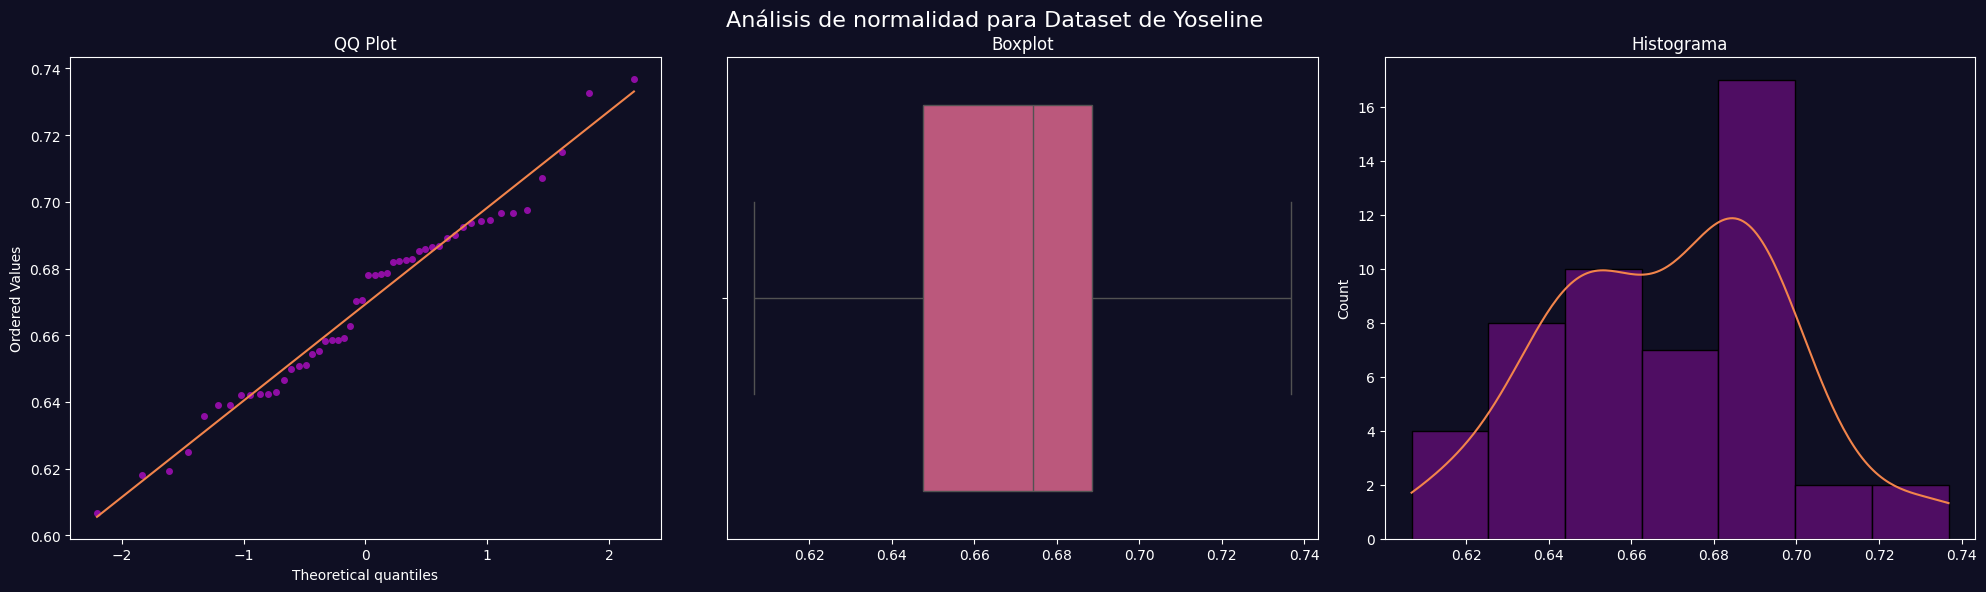

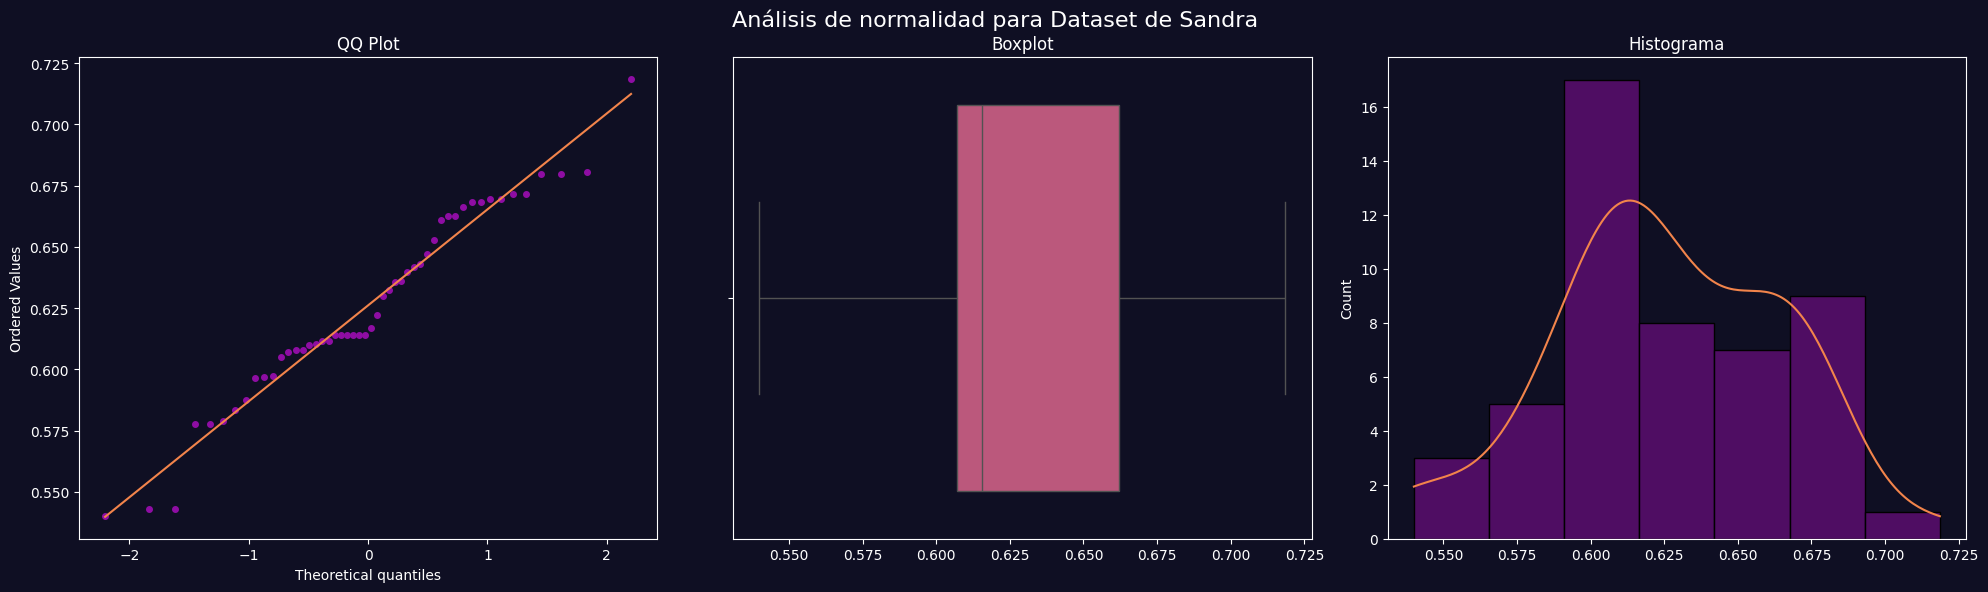

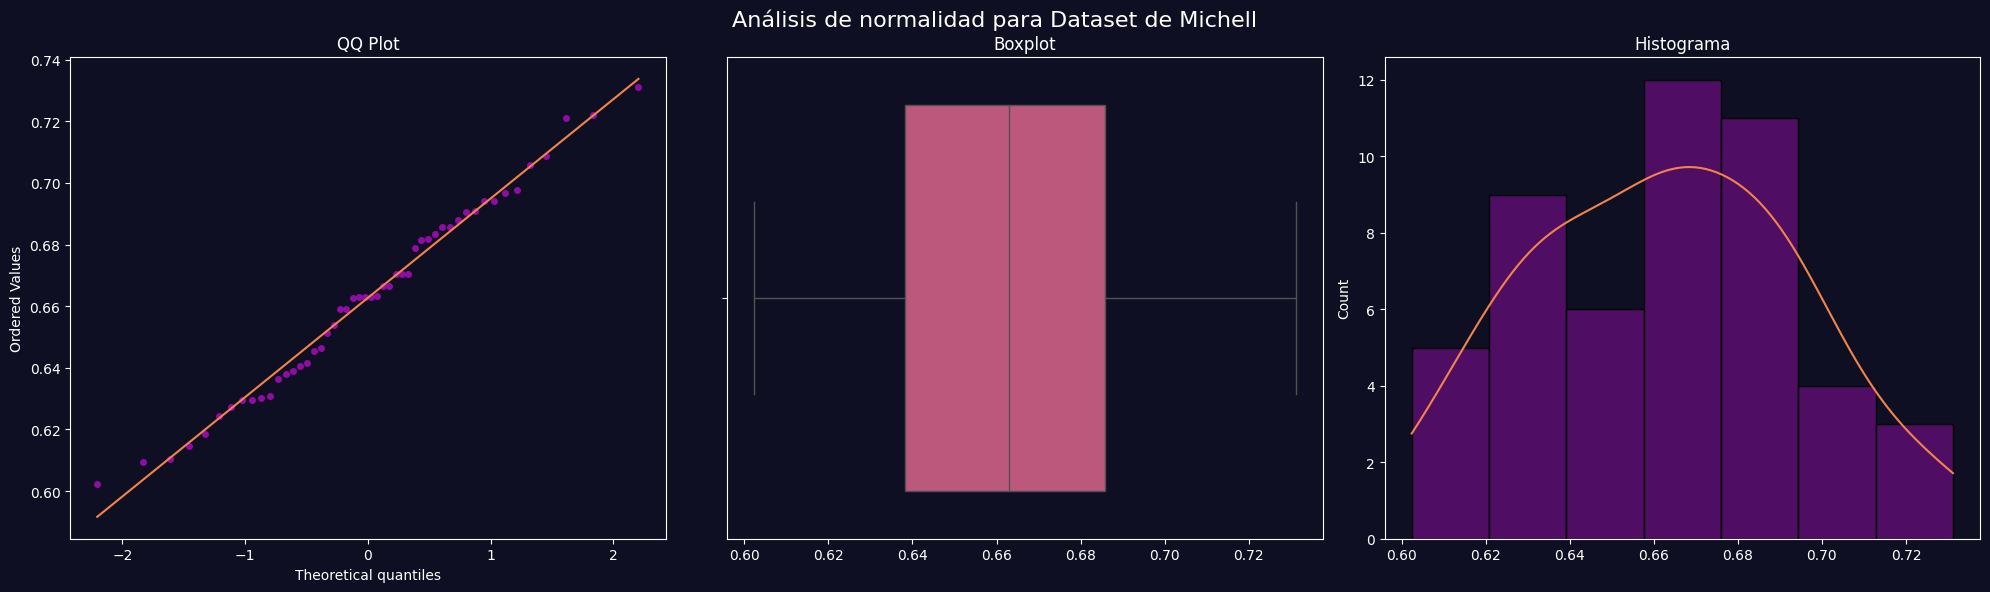

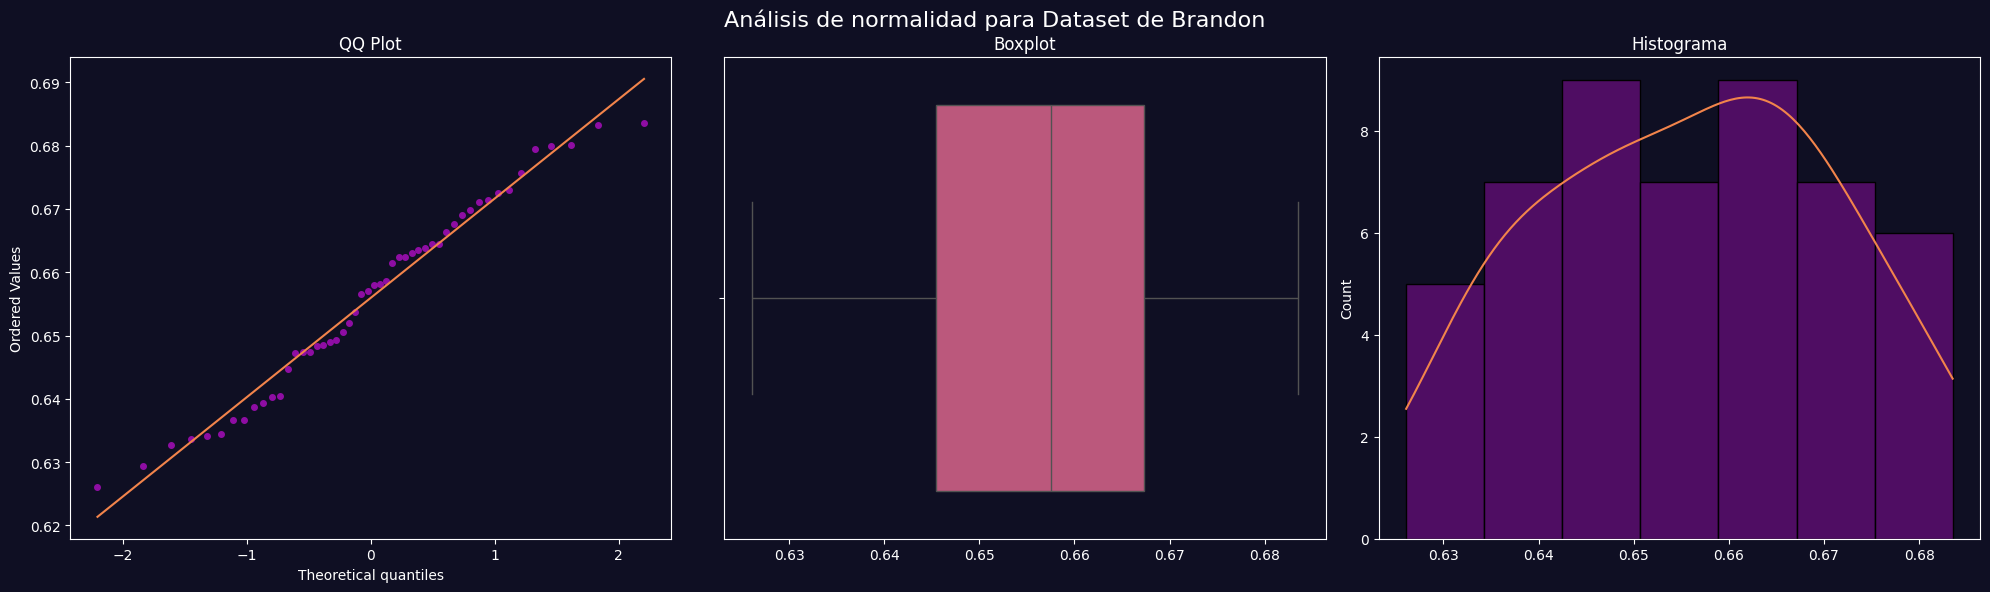

Error in dunn_posthoc_detailed: cannot unpack non-iterable NoneType object
Results successfully saved to statistical_analysis_results.json
Análisis completado. Mostrando resultados numéricos detallados...


In [ ]:
# @title
equipoBINE = {
    "ds_01": ds01,
    "ds_01_name": "Dataset de Yoseline",
    "ds_02": ds02,
    "ds_02_name": "Dataset de Sandra",
    "ds_03": ds03,
    "ds_03_name": "Dataset de Michell",
    "ds_04": ds04,
    "ds_04_name": "Dataset de Brandon",
    "alpha": {
        "values": [0.01, np.arange(0.02, 1, 0.01)],
        "P": 0.5,
        "k": 1,
        "sample_size": 10,
        "iterations": 500
    }
}

# Ejecutar análisis mejorado
print("Iniciando análisis estadístico detallado...")
resultados_detallados = statistical_analysis_detailed(equipoBINE)
print("Análisis completado. Mostrando resultados numéricos detallados...")

In [ ]:
# Mostrar resultados detallados
display_detailed_results_tables(resultados_detallados)

### ⚙️ Parámetros del Análisis

,Parámetro,Valor
0,alpha_level,0.0100
1,total_datasets,4.0000


### 📊 Resumen Estadístico de los Datasets

,Dataset,Muestras,Media,Mediana,Desv. Estándar,Mínimo,Máximo
0,Dataset de Yoseline,50,0.6693,0.6743,0.0282,0.6067,0.7368
1,Dataset de Sandra,50,0.6261,0.6155,0.0384,0.5400,0.7186
2,Dataset de Michell,50,0.6627,0.6629,0.0313,0.6024,0.7312
3,Dataset de Brandon,50,0.6559,0.6575,0.0153,0.6261,0.6835


### 📈 ANÁLISIS DE MÚLTIPLES GRUPOS - RESULTADOS NUMÉRICOS

...

2. Análisis completado para Dataset de Yoseline

3. Análisis completado para Dataset de Sandra

4. Análisis completado para Dataset de Michell

5. Análisis completado para Dataset de Brandon

6. Análisis para múltiples grupos completado